## Frank2D GPU 
### Description
This algorithm is the GPU version of the CPU Frankenstein2D optimized algorithm version.


#### Imports 

In [1]:
import os
import sys
import time
import matplotlib.pyplot as plt
import time

In [2]:
import cupy as cp

In [3]:
current_dir =  os.getcwd()
# replace this following line in the path your frank2d files are.
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

In [4]:
#frank2d
from frank2d_gpu.frank2d_gpu import Frank2D
from frank2d_gpu.geometry import Geometry
from frank2d_gpu.fourier2d_gpu import FourierTransform2D
from frank2d_gpu.preprocess_vis_gpu import Gridding
from frank2d_gpu.plot_gpu import Plot
from frank2d_gpu.constants import rad_to_arcsec, deg_to_rad
from frank2d_gpu.posterior_optimization_gpu import MAPEstimator

### Frank2D GPU

In [5]:
AS209 = {'inc': 34.97, 'pa': 85.76, 'dra':1.9e-3, 'ddec':-2.5e-3, 'rout': 1.2*2, 'disk_name': 'AS209'}
IMLup = {'inc': 47.5, 'pa': 144.5, 'dra':-1.5e-3, 'ddec':1e-3, 'rout': 1.71*2, 'disk_name': 'IMLup'}
Elias27 = {'inc': 56.2, 'pa': 118.8, 'dra':-5e-3, 'ddec':-8e-3, 'rout': 1.88*2, 'disk_name': 'Elias27'}
HD163296 = {'inc':46.7, 'pa':133.33, 'dra':-2.8e-3, 'ddec':7.7e-3, 'rout':1.7*2, 'disk_name': 'HD163296' }
Elias24 = {'inc': 29, 'pa': 45.7, 'dra':110.8e-3, 'ddec':-386.8e-3, 'rout': 1.03*2, 'disk_name': 'Elias24'}
HD143006 = {'inc': 18.6, 'pa': 169, 'dra':-5.9e-3, 'ddec':21.7e-3, 'rout': 0.518*3, 'disk_name': 'HD143006'}

In [6]:
data = AS209

# Huang 2018 
inc = data['inc']
pa = data['pa']
dra = data['dra']
ddec = data['ddec']
rout = data['rout']

In [7]:
dir = "./../../data/"
disk_name = data['disk_name']
data_file = dir +"uvtable_" + disk_name + "_continuum.npz"

In [8]:
# load data
data = cp.load(data_file)
u, v, Re, Imag, Weights = data["u"], data["v"], data["Re"], data["Im"], data["w"]
Vis = Re + Imag*1j

In [9]:
N = 300

In [10]:
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, rout, geom)

In [11]:
uvtable = {'u': u, 'v': v, 'vis': Vis, 'weights': Weights}

In [12]:
frank2d.process_vis(uvtable)

Setting gridded data...


In [13]:
start_time = time.time()

kernel_params =  {'m': -2, 'c': 1e8, 'l': 7e4}
frank2d.fit(kernel_params = kernel_params, rtol = 1e-8 )

end_time = time.time()
print(f"F2D model in {(end_time - start_time):.2f} seconds.")

Setting GP Kernel Wendland...
Creating sparse linear system...


--> time kernel = 0.03  min |  1.64 seconds
--> times building system = 0.03  min |  1.73 seconds
Solving linear system...
Final tolerance :  2.8817519827904934
.... iteration:  0
                        -> actual tol:  288175198.27904934 vs  2.8817519827904934
.... iteration:  1
                        -> actual tol:  39773051.2829406 vs  2.8817519827904934
.... iteration:  2
                        -> actual tol:  30605898.285020407 vs  2.8817519827904934
.... iteration:  3
                        -> actual tol:  31458951.244878978 vs  2.8817519827904934
.... iteration:  4
                        -> actual tol:  32660086.132655557 vs  2.8817519827904934
.... iteration:  5
                        -> actual tol:  32037725.294256493 vs  2.8817519827904934
.... iteration:  6
                        -> actual tol:  68810065.43747628 vs  2.8817519827904934
.... iteration:  7
                        -> actual tol:  30525152.72614929 vs  2.8817519827904934
.... iteration:  8
                

### Best

In [14]:
ME = MAPEstimator(frank2d._Rmax,  frank2d._Geometry)

In [15]:
frank2d.set_MAP_estimator(ME)

Setting MAP estimator...


In [16]:
frank2d.search_MAP(initial_guess={'m': -2, 'logl': 4})

Fitting the visibilities with Frank2D with 2DFT...


 + Total time to evaluate the posterior: 1.23 seconds
  + Time to set up the matrices: 16.60 seconds
Setting the initial guess...
 + Total time to evaluate the posterior: 1.20 seconds
 + Total time to evaluate the posterior: 1.23 seconds
-------x current optimization status:  {'m': -2.0, 'logc': 8.0, 'logl': 4.0}
 + Total time to evaluate the posterior: 1.20 seconds
 + Total time to evaluate the posterior: 1.23 seconds
-------x current optimization status:  {'m': -2.0, 'logc': 8.0, 'logl': 4.0}
Optimizing the posterior...
 + Total time to evaluate the posterior: 1.20 seconds
 + Total time to evaluate the posterior: 1.24 seconds
-------x current optimization status:  {'m': -2.0, 'logc': 8.0, 'logl': 4.0}
 + Total time to evaluate the posterior: 1.20 seconds
 + Total time to evaluate the posterior: 1.23 seconds
-------x current optimization status:  {'m': -2.0, 'logc': 8.1, 'logl': 4.0}
 + Total time to evaluate the posterior: 1.20 seconds
 + Total time to evaluate the posterior: 1.23 se

In [17]:
frank2d.MAP

{'m': array(-1.6416536),
 'c': array(2603040.9159692),
 'l': array(30583.64917986)}

### Plot

In [1]:
import numpy as np

In [2]:
vis_gridded = frank2d.visibility_model

NameError: name 'frank2d' is not defined

In [ ]:
FT = frank2d._FT

In [ ]:
vis_gridded = vis_gridded.get()

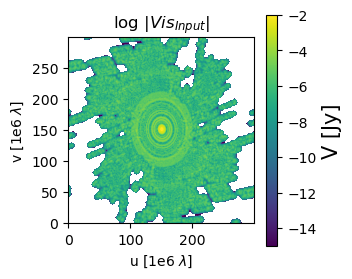

In [ ]:
plt.figure(figsize = (3, 3))
plt.imshow(np.log(np.abs(vis_gridded.reshape(FT._Nx, FT._Ny))), origin='lower', vmin=-15, vmax=-2)
plt.xlabel(r'u [1e6 $\lambda$]')
plt.ylabel(r'v [1e6 $\lambda$]')
plt.title(r'log |$Vis_{Input}$|')
cmap = plt.colorbar()
cmap.set_label(r'V [Jy]', size=15)

In [ ]:
Plot_AS209 = Plot(frank2d, geom)

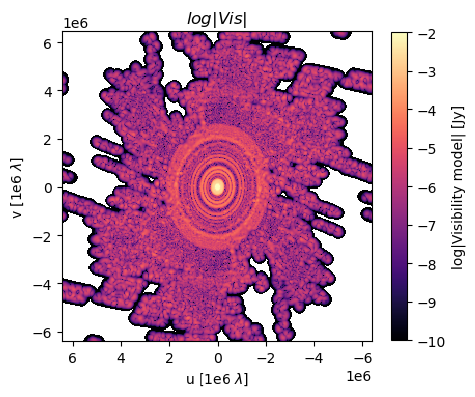

In [ ]:
Plot_AS209.visibility(fig_size = 5, kind = 'model')

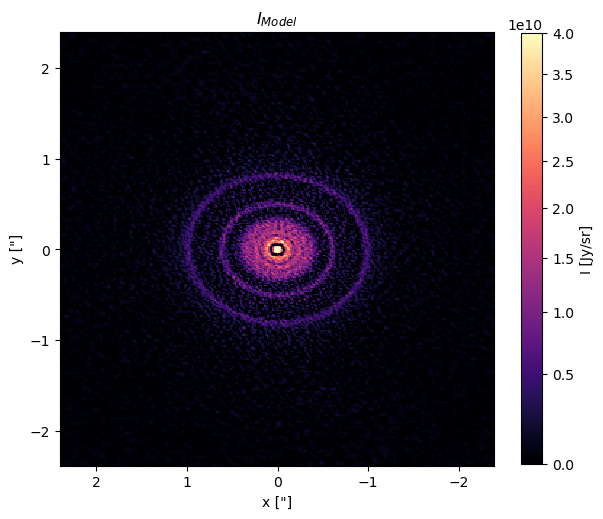

In [ ]:
Plot_AS209.intensity(fig_size = 7, vmax = 4e10, gamma = 0.75)

In [ ]:
uvtable = {"u": u.get(), "v": v.get(), "vis": Vis.get(), "weights": Weights.get()}

Performing 1D Frank fit...


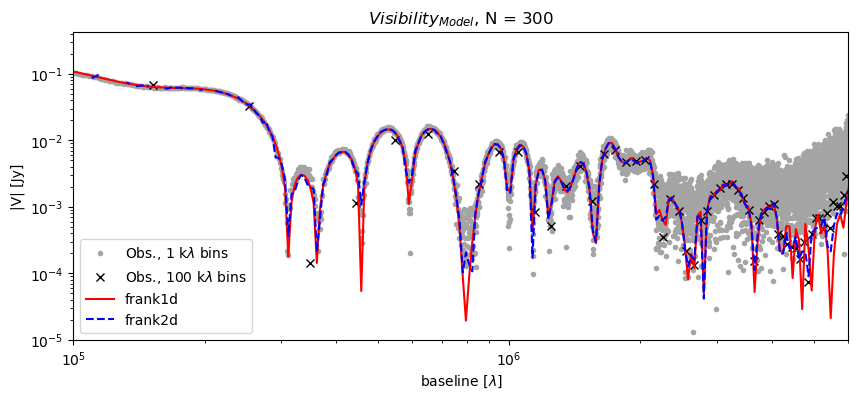

In [ ]:
Plot_AS209.visibility_profile(input = uvtable, weighted = True, frank1d = True)

Performing 1D Frank fit...


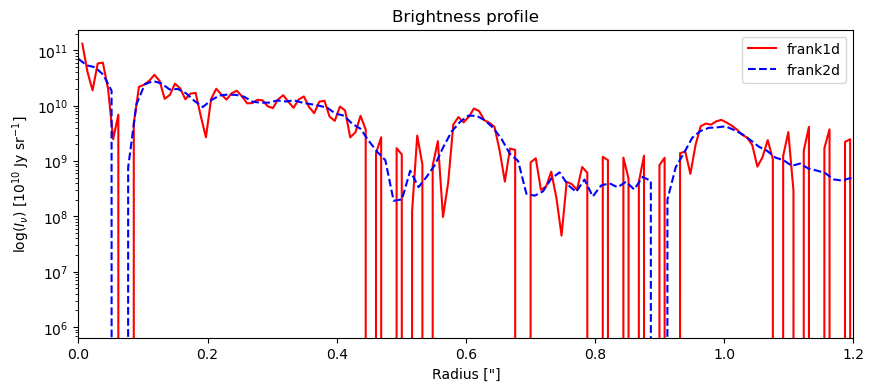

In [ ]:
Plot_AS209.intensity_profile(clean = False)

In [ ]:
dir_fits =  dir
disk_fits = disk_name + '_continuum.fits'
fits_file = dir_fits + disk_fits

	 Reverting to standard azimuthal averaging; will ignore `unit` argument.


Clean beam: 0.038216292858108 x 0.036224924027904 arcsec
Performing 1D Frank fit...


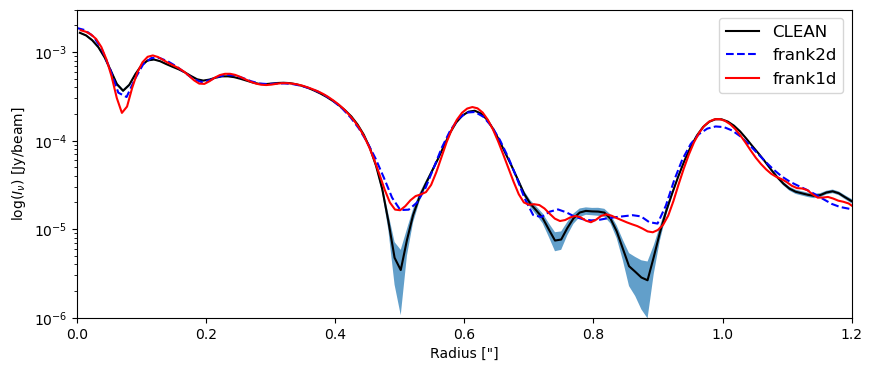

In [ ]:
Plot_AS209.intensity_profile(clean = True, fits_file = fits_file)